# 02_b_binary_codes.ipynb

本文件用于生成 `02_a_binary_lec.qmd` 所需的**模拟数据**与**讲义插图**。

## 本文件的功能

- 生成一份可复现的模拟数据：`./data/corporate_default.csv`
- 生成本章讲义中的 4 幅基础图形
- 输出少量 sanity checks，用于核验数据生成过程是否合理
- **不承担完整案例分析任务**；模型估计、预测评价与更深入的应用分析，放在 `03_c_binary_case.ipynb` 中展开

## 图形列表

- `./figs/limit_dep_binary_fig01_scatter.png`
- `./figs/limit_dep_binary_fig02_lpm_vs_logit.png`
- `./figs/limit_dep_binary_fig03_link_functions.png`
- `./figs/limit_dep_binary_fig04_latent_variable.png`


In [1]:
# ============================================================
# 0. 环境准备与路径设置
# ============================================================

from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.special import expit
import statsmodels.api as sm

warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# 图形显示与中文支持
# ------------------------------------------------------------
plt.rcParams["font.sans-serif"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False

# ------------------------------------------------------------
# 路径设置
# ------------------------------------------------------------
FIG_DIR = Path("./figs")
DATA_DIR = Path("./data")

FIG_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# 文件名注册表
# 说明：
# 1. 统一使用 limit_dep_binary_ 前缀，避免全书图片重名
# 2. 后续若将图片上传到图床，文件名也能保持唯一性
# ------------------------------------------------------------
FIGS = {
    "fig01": "limit_dep_binary_fig01_scatter.png",
    "fig02": "limit_dep_binary_fig02_lpm_vs_logit.png",
    "fig03": "limit_dep_binary_fig03_link_functions.png",
    "fig04": "limit_dep_binary_fig04_latent_variable.png",
}

DATA_FILE = DATA_DIR / "corporate_default.csv"

# ------------------------------------------------------------
# 统一的绘图参数
# ------------------------------------------------------------
DPI = 300
LINEWIDTH = 1.8

# ------------------------------------------------------------
# 配色方案
# ------------------------------------------------------------
BLUE = "#4C78A8"
ORANGE = "#F58518"
GRAY = "#7F7F7F"
GREEN = "#54A24B"


## 1. 数据生成过程（DGP）：模型说明

本章采用如下潜在指数模型来生成企业违约数据。设潜在变量为：

$$
y_i^* = \eta_i + \varepsilon_i
$$

其中，

$$
\eta_i
= \beta_0
+ \beta_1 \, size_i
+ \beta_2 \, leverage_i
+ \beta_3 \, roa_i
+ \beta_4 \, age_i
+ \gamma' \, industry_i
+ \delta' \, ownership_i
$$

观测到的二元结果变量为：

$$
y_i =
\begin{cases}
1, & y_i^* > 0 \\
0, & y_i^* \le 0
\end{cases}
$$

等价地，也可以写成条件概率形式：

$$
P(y_i = 1 \mid \mathbf{x}_i) = \Lambda(\eta_i),
\qquad
\Lambda(z) = \frac{e^z}{1 + e^z}
$$

### 设计思路

- `size`、`leverage`、`roa`、`age` 通过相关结构联合生成，使模拟数据更接近企业财务变量的现实特征；
- 加入行业异质性与所有制异质性；
- 让 `leverage` 提高违约概率，`size`、`roa`、`age` 降低违约概率；
- 最终得到一份既适合课堂图示，也适合案例分析的模拟样本。


In [2]:
# ============================================================
# 2. DGP：参数设定
# ============================================================

# 为保证结果可复现，固定随机种子
np.random.seed(42)

# 样本量
N = 1000

# ------------------------------------------------------------
# 2.1 连续变量部分的参数设定
# 变量顺序：[size, leverage, roa, age]
# ------------------------------------------------------------

MEAN_VECTOR = np.array([
    15.8,   # size: 企业规模（可理解为 ln 总资产）
    0.46,   # leverage: 杠杆率
    0.055,  # roa: 总资产收益率
    14.0    # age: 企业年龄
])

STD_VECTOR = np.array([
    1.15,   # size 的标准差
    0.16,   # leverage 的标准差
    0.035,  # roa 的标准差
    6.50    # age 的标准差
])

# 相关矩阵：体现企业财务变量之间的经验关系
CORR_MATRIX = np.array([
    [ 1.00, -0.30,  0.25,  0.40],
    [-0.30,  1.00, -0.20, -0.10],
    [ 0.25, -0.20,  1.00,  0.10],
    [ 0.40, -0.10,  0.10,  1.00]
])

# ------------------------------------------------------------
# 2.2 系数参数：控制违约概率的结构
# ------------------------------------------------------------
BETA = {
    "const": -3.80,
    "size": -0.32,
    "leverage": 4.80,
    "roa": -7.50,
    "age": -0.03,
}

INDUSTRY_EFFECT = {
    "manufacturing": 0.00,
    "real_estate": 0.55,
    "finance": -0.45,
    "tech": -0.18,
}

OWNERSHIP_EFFECT = {
    "private": 0.00,
    "state": -0.28,
}


In [3]:
# ============================================================
# 3. DGP：生成模拟数据
# ============================================================

# ------------------------------------------------------------
# 3.1 生成连续变量
# 使用 Cholesky 分解构造相关结构
# ------------------------------------------------------------
cov_matrix = np.diag(STD_VECTOR) @ CORR_MATRIX @ np.diag(STD_VECTOR)
L = np.linalg.cholesky(cov_matrix)

# 先生成独立标准正态变量，再通过线性变换得到相关变量
z = np.random.normal(size=(N, 4))
x_cont = z @ L.T + MEAN_VECTOR

df = pd.DataFrame(x_cont, columns=["size", "leverage", "roa", "age"])

# 为了更贴近财务数据的取值范围，对变量做边界裁剪
df["size"] = df["size"].clip(11.0, 20.0)
df["leverage"] = df["leverage"].clip(0.05, 0.95)
df["roa"] = df["roa"].clip(-0.12, 0.20)
df["age"] = df["age"].clip(1.0, 35.0)

# ------------------------------------------------------------
# 3.2 生成类别变量：行业与所有制
# ------------------------------------------------------------
industries = ["manufacturing", "real_estate", "finance", "tech"]
industry_probs = [0.42, 0.18, 0.15, 0.25]
df["industry"] = np.random.choice(industries, size=N, p=industry_probs)

# 所有制概率可与规模略相关：大企业更容易是国企
state_prob = expit(-1.0 + 0.20 * (df["size"] - df["size"].mean()))
df["ownership"] = np.where(
    np.random.uniform(size=N) < state_prob,
    "state",
    "private"
)

# ------------------------------------------------------------
# 3.3 对连续变量加入类别异质性调整
# 这样做的目的，是让行业与所有制不仅直接影响违约概率，
# 也体现在财务结构分布上，使模拟样本更自然
# ------------------------------------------------------------

# 地产企业杠杆更高；金融企业规模更大、杠杆较平稳；科技企业更年轻、ROA 波动稍大
df.loc[df["industry"] == "real_estate", "leverage"] += 0.08
df.loc[df["industry"] == "finance", "size"] += 0.45
df.loc[df["industry"] == "finance", "age"] += 2.0
df.loc[df["industry"] == "tech", "age"] -= 3.0
df.loc[df["industry"] == "tech", "roa"] += 0.008

# 国企通常规模更大、杠杆略低、年龄更长
is_state = df["ownership"] == "state"
df.loc[is_state, "size"] += 0.45
df.loc[is_state, "leverage"] -= 0.03
df.loc[is_state, "age"] += 2.5

# 再次裁剪，避免超出区间
df["size"] = df["size"].clip(11.0, 20.5)
df["leverage"] = df["leverage"].clip(0.05, 0.95)
df["roa"] = df["roa"].clip(-0.12, 0.20)
df["age"] = df["age"].clip(1.0, 40.0)

# ------------------------------------------------------------
# 3.4 构造潜在指数 eta，并生成违约概率与二元违约结果
# ------------------------------------------------------------
eta = (
    BETA["const"]
    + BETA["size"] * df["size"]
    + BETA["leverage"] * df["leverage"]
    + BETA["roa"] * df["roa"]
    + BETA["age"] * df["age"]
    + df["industry"].map(INDUSTRY_EFFECT)
    + df["ownership"].map(OWNERSHIP_EFFECT)
)

# 采用 logistic CDF 生成违约概率
df["p_default"] = expit(eta)

# 根据违约概率抽取二元违约状态
df["default"] = np.random.binomial(1, df["p_default"])

# ------------------------------------------------------------
# 3.5 保存数据
# ------------------------------------------------------------
df.to_csv(DATA_FILE, index=False, encoding="utf-8-sig")

print(f"数据已保存：{DATA_FILE}")
print(f"样本量：{len(df):,}")
print(df.head().round(3))


数据已保存：data\corporate_default.csv
样本量：1,000
     size  leverage    roa     age       industry ownership  p_default  \
0  16.821     0.465  0.082  26.855    real_estate     state      0.000   
1  15.531     0.436  0.107  17.959  manufacturing   private      0.000   
2  15.260     0.565  0.041   7.071           tech   private      0.001   
3  16.528     0.206  0.008  13.487    real_estate     state      0.000   
4  15.085     0.557  0.014   4.981        finance   private      0.001   

   default  
0        0  
1        0  
2        0  
3        0  
4        0  


## 2. 图 1：二元因变量与协变量的关系

这幅图用于说明：当因变量是二元变量时，散点图会出现明显的离散堆叠结构；同时，不同组别在关键协变量上的分布也可能存在系统差异。

- 左图：`default` 与 `leverage`、`size` 的联合分布
- 中图：不同违约状态下的 `leverage` 分布
- 右图：不同违约状态下的 `size` 分布

本图主要服务于讲义中“为什么线性模型在二元因变量场景下不够理想”的直观引入。


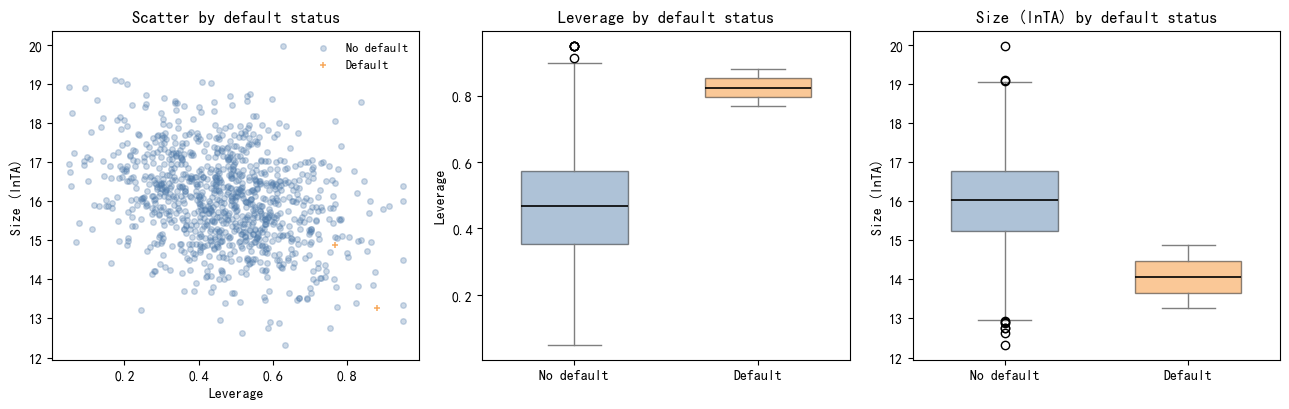

图形已保存：figs\limit_dep_binary_fig01_scatter.png


In [4]:
# ============================================================
# 4. 图 1：散点图 + 分组箱线图
# ============================================================

d0 = df[df["default"] == 0]
d1 = df[df["default"] == 1]

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))

# ------------------------------------------------------------
# 左图：scatter
# ------------------------------------------------------------
ax = axes[0]
ax.scatter(
    d0["leverage"], d0["size"],
    alpha=0.28, s=16, color=BLUE, marker="o", label="No default"
)
ax.scatter(
    d1["leverage"], d1["size"],
    alpha=0.70, s=24, color=ORANGE, marker="+", linewidths=1.1, label="Default"
)
ax.set_xlabel("Leverage")
ax.set_ylabel("Size (lnTA)")
ax.legend(frameon=False, fontsize=9)
ax.set_title("Scatter by default status")

# ------------------------------------------------------------
# 中图与右图：箱线图
# ------------------------------------------------------------
for ax, var, ylabel in [
    (axes[1], "leverage", "Leverage"),
    (axes[2], "size", "Size (lnTA)")
]:
    box = ax.boxplot(
        [d0[var], d1[var]],
        labels=["No default", "Default"],
        patch_artist=True,
        widths=0.58,
        medianprops=dict(color="black", linewidth=1.2),
        whiskerprops=dict(color=GRAY),
        capprops=dict(color=GRAY),
    )
    box["boxes"][0].set(facecolor=BLUE, alpha=0.45)
    box["boxes"][1].set(facecolor=ORANGE, alpha=0.45)
    ax.set_ylabel(ylabel)
    ax.set_title(f"{ylabel} by default status")

fig.tight_layout()

fig_path = FIG_DIR / FIGS["fig01"]
fig.savefig(fig_path, dpi=DPI, bbox_inches="tight")
plt.show()

print(f"图形已保存：{fig_path}")


## 3. 图 2：LPM 与 Logit 的拟合概率对比

这幅图用于说明：

- LPM 的拟合结果是线性的，容易解释；
- 但在线性外推时，预测值可能落在 $[0,1]$ 区间之外；
- Logit 使用 S 型函数将预测概率限制在合法区间内。

这里仅用单变量 `leverage` 做示意，以保持图形直观清晰；完整多变量设定放在 `03_c_binary_case.ipynb` 中展开。


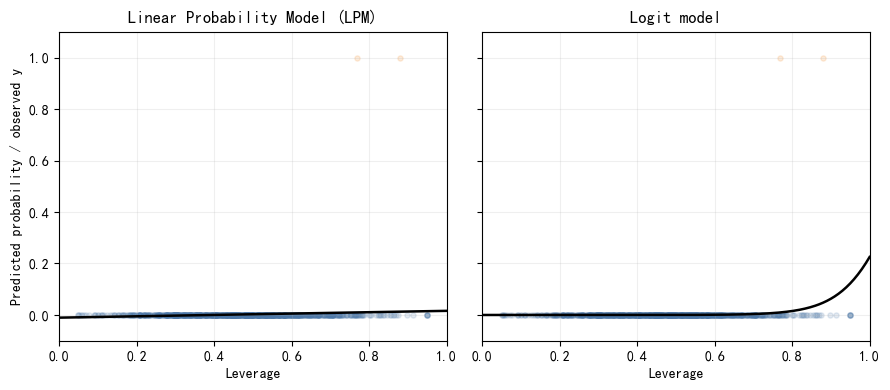

图形已保存：figs\limit_dep_binary_fig02_lpm_vs_logit.png


In [5]:
# ============================================================
# 5. 图 2：LPM vs Logit
# ============================================================

y = df["default"].values
X1 = sm.add_constant(df[["leverage"]])

# LPM：直接用 OLS 拟合二元因变量
lpm_model = sm.OLS(y, X1).fit()

# Logit：使用 leverage 解释违约概率
logit_model = sm.Logit(y, X1).fit(disp=0)

# 构造 leverage 的网格点，用于绘制拟合曲线
lev_grid = np.linspace(0.0, 1.0, 300)
X_grid = sm.add_constant(pd.DataFrame({"leverage": lev_grid}))

fig, axes = plt.subplots(1, 2, figsize=(9, 4), sharey=True)

for ax, fitted_prob, title in zip(
    axes,
    [lpm_model.predict(X_grid), logit_model.predict(X_grid)],
    ["Linear Probability Model (LPM)", "Logit model"]
):
    # 背景中显示观测点，帮助读者理解二元结果的离散性
    for yi, color in [(0, BLUE), (1, ORANGE)]:
        mask = (y == yi)
        ax.scatter(
            df.loc[mask, "leverage"],
            y[mask],
            s=14,
            alpha=0.15,
            color=color
        )

    # 叠加拟合概率曲线
    ax.plot(lev_grid, fitted_prob, color="black", linewidth=LINEWIDTH)
    ax.set_title(title)
    ax.set_xlabel("Leverage")
    ax.set_ylim(-0.10, 1.10)
    ax.set_xlim(0.0, 1.0)
    ax.grid(alpha=0.20)

axes[0].set_ylabel("Predicted probability / observed y")

fig.tight_layout()

fig_path = FIG_DIR / FIGS["fig02"]
fig.savefig(fig_path, dpi=DPI, bbox_inches="tight")
plt.show()

print(f"图形已保存：{fig_path}")


## 4. 图 3：三种链接函数

这幅图用于比较：

- LPM：线性概率近似；
- Logit：logistic CDF；
- Probit：normal CDF。

它服务于讲义中“二元选择模型的函数形式”这一部分，重点不是比较预测精度，而是帮助学生理解不同模型如何把线性指数 $\mathbf{x}_i' \beta$ 映射为概率。


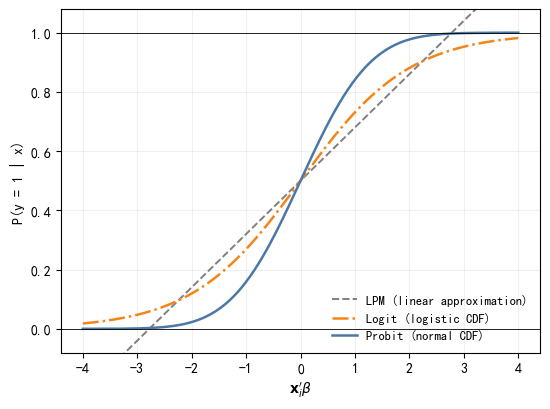

图形已保存：figs\limit_dep_binary_fig03_link_functions.png


In [6]:
# ============================================================
# 6. 图 3：链接函数对比
# ============================================================

u = np.linspace(-4, 4, 400)

fig, ax = plt.subplots(figsize=(5.6, 4.2))

# LPM 在这里画成一条线性近似线，仅用于示意
ax.plot(
    u, 0.5 + 0.18 * u,
    linewidth=1.4, linestyle="--", color=GRAY,
    label="LPM (linear approximation)"
)
ax.plot(
    u, expit(u),
    linewidth=LINEWIDTH, linestyle="-.", color=ORANGE,
    label="Logit (logistic CDF)"
)
ax.plot(
    u, stats.norm.cdf(u),
    linewidth=LINEWIDTH, linestyle="-", color=BLUE,
    label="Probit (normal CDF)"
)

ax.axhline(0, color="black", linewidth=0.6)
ax.axhline(1, color="black", linewidth=0.6)
ax.set_xlabel(r"$\mathbf{x}_i' \beta$")
ax.set_ylabel("P(y = 1 | x)")
ax.set_ylim(-0.08, 1.08)
ax.grid(alpha=0.18)
ax.legend(frameon=False, fontsize=9, loc="lower right")

fig.tight_layout()

fig_path = FIG_DIR / FIGS["fig03"]
fig.savefig(fig_path, dpi=DPI, bbox_inches="tight")
plt.show()

print(f"图形已保存：{fig_path}")


## 5. 图 4：潜变量与观测到的二元结果

这幅图用于说明潜变量解释：

$$
y_i^* = \alpha + \beta x_i + \varepsilon_i
$$

以及

$$
y_i = 1(y_i^* > 0)
$$

左图展示潜变量 $y_i^*$ 与阈值 0 的关系；右图展示在阈值规则下，如何从连续的潜变量映射为观测到的二元结果。


In [7]:
# ============================================================
# 7. 图 4：latent variable
# ============================================================

# 单独固定一个随机种子，确保本图可独立复现
np.random.seed(12348)

n_lat = 400
x_lat = np.random.uniform(0, 10, n_lat)
e_lat = np.random.normal(0, 1, n_lat)

# 这里使用一个简单的潜变量模型，仅用于图示
y_star = -3.0 + 0.6 * x_lat + e_lat
y_obs = (y_star > 0).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.6))

# ------------------------------------------------------------
# 左图：潜变量散点图
# ------------------------------------------------------------
ax = axes[0]
mask_pos = y_star > 0
mask_neg = ~mask_pos

ax.scatter(
    x_lat[mask_neg], y_star[mask_neg],
    alpha=0.45, s=18, color=BLUE, label=r"$y_i^* \le 0$"
)
ax.scatter(
    x_lat[mask_pos], y_star[mask_pos],
    alpha=0.55, s=18, color=ORANGE, label=r"$y_i^* > 0$"
)

# 理论直线 E(y* | x)
x_line = np.linspace(0, 10, 200)
ax.plot(x_line, -3.0 + 0.6 * x_line, color="black", linewidth=LINEWIDTH)

ax.axhline(0, color=GRAY, linestyle="--", linewidth=1.2)
ax.set_xlabel("x")
ax.set_ylabel(r"Latent variable $y_i^*$")
ax.set_title(r"Latent index and threshold")
ax.legend(frameon=False, fontsize=9)
ax.grid(alpha=0.18)

# ------------------------------------------------------------
# 右图：观测到的二元结果
# ------------------------------------------------------------
ax = axes[1]
ax.scatter(
    x_lat[mask_neg], y_obs[mask_neg],
    alpha=0.35, s=18, color=BLUE, label=r"$y_i = 0$"
)
ax.scatter(
    x_lat[mask_pos], y_obs[mask_pos],
    alpha=0.55, s=18, color=ORANGE, label=r"$y_i = 1$"
)

# 用滚动均值近似展示 x 增大时 y=1 的概率上升
order = np.argsort(x_lat)
x_sorted = x_lat[order]
y_sorted = y_obs[order]
window = 35
y_smooth = pd.Series(y_sorted).rolling(window=window, center=True).mean()

ax.plot(x_sorted, y_smooth, color="black", linewidth=LINEWIDTH)
ax.set_xlabel("x")
ax.set_ylabel(r"Observed binary outcome $y_i$")
ax.set_yticks([0, 1])
ax.set_ylim(-0.15, 1.15)
ax.set_title(r"Observed binary outcome")
ax.legend(frameon=False, fontsize=9, loc="center right")
ax.grid(alpha=0.18)

fig.tight_layout()

fig_path = FIG_DIR / FIGS["fig04"]
fig.savefig(fig_path, dpi=DPI, bbox_inches="tight")
plt.show()

print(f"图形已保存：{fig_path}")


ValueError: 
y_i^* \le 0
      ^
ParseFatalException: Unknown symbol: \le, found '\'  (at char 6), (line:1, col:7)

Error in callback <function _draw_all_if_interactive at 0x000001B9A49191C0> (for post_execute), with arguments args (),kwargs {}:


ValueError: 
y_i^* \le 0
      ^
ParseFatalException: Unknown symbol: \le, found '\'  (at char 6), (line:1, col:7)

ValueError: 
y_i^* \le 0
      ^
ParseFatalException: Unknown symbol: \le, found '\'  (at char 6), (line:1, col:7)

<Figure size 1000x460 with 2 Axes>

## 6. Sanity checks

下面只保留少量核验输出，用于确认：

- 违约率是否处于合理区间；
- 连续变量之间是否保留了预期的相关结构；
- 国企与民企在财务特征上是否存在一定差异。

更完整的描述统计、模型估计、边际效应与预测评价，放在 `03_c_binary_case.ipynb` 中完成。


In [8]:
# ============================================================
# 8. Sanity checks
# ============================================================

print("=== 样本概览 ===")
print(f"样本量: {len(df):,}")
print(f"总体违约率: {df['default'].mean():.3f}")

print("\n=== 所有制分组违约率 ===")
print(df.groupby("ownership")["default"].mean().round(3))

print("\n=== 行业分组违约率 ===")
print(df.groupby("industry")["default"].mean().round(3))

print("\n=== 连续变量相关矩阵 ===")
print(df[["size", "leverage", "roa", "age"]].corr().round(2))

print("\n=== 所有制分组的连续变量均值 ===")
print(df.groupby("ownership")[["size", "leverage", "roa", "age"]].mean().round(3))


=== 样本概览 ===
样本量: 1,000
总体违约率: 0.002

=== 所有制分组违约率 ===
ownership
private    0.003
state      0.000
Name: default, dtype: float64

=== 行业分组违约率 ===
industry
finance          0.007
manufacturing    0.000
real_estate      0.005
tech             0.000
Name: default, dtype: float64

=== 连续变量相关矩阵 ===
          size  leverage   roa   age
size      1.00     -0.31  0.19  0.41
leverage -0.31      1.00 -0.21 -0.11
roa       0.19     -0.21  1.00  0.08
age       0.41     -0.11  0.08  1.00

=== 所有制分组的连续变量均值 ===
             size  leverage    roa     age
ownership                                 
private    15.826     0.484  0.056  13.722
state      16.545     0.428  0.058  16.653
